In [1]:
import pickle
import os

from IPython.display import display

from system_config import *
from construction_config import *
import construct.analysis as analysis

import ui

# import webbrowser
# from ui.explanations import explanations 
# import pandas as pd
# import matplotlib.pyplot as plt
# import os


current_data = "/home/avi/Desktop/robomason/_workingdata/Development/sample_raw_data.pkl"

# Load the pickle file
with open(current_data, 'rb') as f:
    pos_data = pickle.load(f)

ModuleNotFoundError: No module named 'system_config'

In [3]:
# import numpy as np
# import pandas as pd

# def analyse_segment(_pos_data):
#     segments = analysis.segment_data(_pos_data)
#     plots = []
#     for i in range(len(segments)):
#         print(segments[i]['instance'])
#         fig_vel, fig_acc, _, _, _ = analysis.calculate_velocity_acceleration_plot(segments[i],
#                                                                          segments[0]['grab'][0])
#         figures = analysis.plot_complete_data(segments[i]['grab'],
#                                               segments[i]['instance'])

#         packet = {
#             'segment':segments[i]['instance'],
#             'kinematic plots': [fig_vel, fig_acc],
#             'trajectory_plots': [figures],
#         }
        
#         if i == 0:
#             fov_plotter = analysis.FOVPlotter()
#             FOV_figures = fov_plotter.plot_FOV(segments[0]['grab'], view="2d", representation="area")
#             packet['FOV'] = FOV_figures
#         plots.append(packet)
#     return plots

# def calculate_euclidean_distance(point1, point2):
#     """Calculate the Euclidean distance between two points."""
#     return np.linalg.norm(np.array(point1) - np.array(point2))

# def summarize_trajectory_metrics(pos_data, hazard_events=None):
#     """
#     Summarizes trajectory metrics by segment (each unique consecutive element+state).
#     Skips any data packets where element or state is None.
#     Returns a DataFrame with summary statistics, plus a "Hazard Event" column.

#     Parameters:
#         pos_data (list of dict): Robot trajectory data, each dict has keys:
#             'element', 'state', 'coordinates', 'timestamp_send', etc.
#         hazard_events (list of dict or None): Hazard event data, each dict has keys:
#             'start_time', 'end_time', 'element', 'state', 'worker_id' (optional), etc.
#             If None, we skip hazard checks.

#     Returns:
#         pd.DataFrame: One row per segment with columns:
#             - Element
#             - State
#             - ArUco ID
#             - Start [x,y,z]
#             - End [x,y,z]
#             - Start Time [s]
#             - End Time [s]
#             - Elapsed Time [s]
#             - Average Velocity [m/s]
#             - Average Acceleration [m/s²]
#             - Traversed Length [m]
#             - Path Efficiency [%]
#             - Average Curvature [radians]
#             - Hazard Event
#     """

#     def round_coordinates(coord):
#         if isinstance(coord, list):
#             return [round(val, 2) for val in coord]
#         return coord

#     # Define the construction phases with ArUco IDs
#     construction_phases = {
#         "Scanning site": '[0],[1],[2]',
#         "Searching element": '-',
#         "Foundation": '[11]',
#         "Toilet": '-',
#         "Wall": '[10]',
#         "Floor": '[12]'
#     }

#     # Prepare lists for final DataFrame
#     elements = []
#     states = []
#     start_coords = []
#     end_coords = []
#     start_times = []
#     end_times = []
#     traversed_lengths = []
#     path_efficiencies = []
#     curvatures = []
#     aruco_ids = []
#     elapsed_times = []
#     avg_velocities = []
#     avg_accelerations = []
#     hazard_descriptions = []  # <-- New: store hazard event info

#     # If no data, return empty DF
#     if not pos_data:
#         return pd.DataFrame()

#     # --- 1) Find the first valid data packet to initialize ---
#     idx = 0
#     while idx < len(pos_data):
#         if (pos_data[idx]['element'] is not None) and (pos_data[idx]['state'] is not None):
#             break
#         idx += 1

#     # If we never found a valid packet, return empty
#     if idx == len(pos_data):
#         return pd.DataFrame()

#     # Initialize references for the first valid packet
#     initial_timestamp = pos_data[idx]['timestamp_send']
#     prev_element = pos_data[idx]['element'].strip()
#     prev_state   = pos_data[idx]['state'].strip()
#     start_coord  = pos_data[idx]['coordinates']
#     start_time   = pos_data[idx]['timestamp_send']
#     prev_coordinates = start_coord
#     prev_direction   = None
#     total_length     = 0.0
#     total_curvature  = 0.0
#     segment_count    = 0
#     start_velocity   = 0.0

#     # Helper to compute hazard event description for a given segment
#     def get_hazard_description(element, state, seg_start, seg_end):
#         """
#         Return a neatly formatted string describing hazard events that:
#           1) Overlap in time with the segment [seg_start, seg_end].
#           2) Match the same element+state.
        
#         The timestamps are converted to relative times (relative to initial_timestamp).
#         """
#         if not hazard_events:
#             return "No hazard"

#         overlapping = []
#         for h in hazard_events:
#             # Only consider hazard events matching the same element and state.
#             if h.get('element') != element or h.get('state') != state:
#                 continue

#             h_start = h['start_time']
#             h_end   = h['end_time']

#             # Check if hazard overlaps the segment.
#             if h_end >= seg_start and h_start <= seg_end:
#                 rel_start = h_start - initial_timestamp
#                 rel_end   = h_end - initial_timestamp
#                 worker_id = h.get('worker_id')
#                 if worker_id is not None:
#                     overlapping.append(f"Worker {worker_id} from {rel_start:.2f}s to {rel_end:.2f}s")
#                 else:
#                     overlapping.append(f"Hazard from {rel_start:.2f}s to {rel_end:.2f}s")
#         return " | ".join(overlapping) if overlapping else "No hazard"

#     # Helper function to finalize the current segment
#     def finalize_segment(end_time, end_coord):
#         """Append one row of metrics for the current segment."""
#         elements.append(prev_element)
#         states.append(prev_state)
#         start_coords.append(round_coordinates(start_coord))
#         end_coords.append(round_coordinates(end_coord))

#         # Calculate times relative to the initial timestamp
#         seg_start_s = start_time
#         seg_end_s   = end_time
#         seg_elapsed = end_time - start_time

#         start_times.append(round(seg_start_s - initial_timestamp, 2))
#         end_times.append(round(seg_end_s - initial_timestamp, 2))
#         elapsed_times.append(round(seg_elapsed, 2))

#         total_dist = round(total_length, 2)
#         traversed_lengths.append(total_dist)

#         # Path efficiency calculation
#         straight_line_distance = calculate_euclidean_distance(start_coord, end_coord)
#         path_eff = (straight_line_distance / total_length * 100.0) if total_length > 0 else 100.0
#         path_efficiencies.append(round(path_eff, 2))

#         # Average curvature
#         avg_curv = total_curvature / segment_count if segment_count > 0 else 0.0
#         curvatures.append(round(avg_curv, 2))

#         # ArUco ID
#         aruco_ids.append(construction_phases.get(prev_element, '-'))

#         # Average velocity and acceleration
#         avg_vel = total_length / seg_elapsed if seg_elapsed > 0 else 0.0
#         avg_velocities.append(round(avg_vel, 2))
#         avg_acc = (avg_vel - start_velocity) / seg_elapsed if seg_elapsed > 0 else 0.0
#         avg_accelerations.append(round(avg_acc, 2))

#         # --- New: hazard event description (using relative timestamps) ---
#         hazard_info = get_hazard_description(prev_element, prev_state, seg_start_s, seg_end_s)
#         hazard_descriptions.append(hazard_info)

#         return avg_vel  # so we can update start_velocity

#     # --- 2) Main loop from the next packet onwards ---
#     i = idx + 1
#     while i < len(pos_data):
#         data = pos_data[i]
#         i += 1

#         # Skip if element or state is None
#         if data['element'] is None or data['state'] is None:
#             continue

#         element     = data['element'].strip()
#         state       = data['state'].strip()
#         coordinates = data['coordinates']
#         timestamp   = data['timestamp_send']

#         # Check if we are continuing the same segment or not
#         if element == prev_element and state == prev_state:
#             dist = calculate_euclidean_distance(prev_coordinates, coordinates)
#             total_length += dist

#             # Curvature calculation
#             current_direction = np.array(coordinates) - np.array(prev_coordinates)
#             norm = np.linalg.norm(current_direction)
#             if norm > 1e-9:
#                 current_direction /= norm
#                 if prev_direction is not None:
#                     cosine_angle = np.clip(np.dot(prev_direction, current_direction), -1.0, 1.0)
#                     angle_change = np.arccos(cosine_angle)
#                     total_curvature += angle_change
#                     segment_count += 1
#                 prev_direction = current_direction

#         else:
#             # Finalize the current segment and reset for new one.
#             start_velocity = finalize_segment(timestamp, prev_coordinates)
#             prev_element   = element
#             prev_state     = state
#             start_coord    = coordinates
#             start_time     = timestamp
#             total_length   = 0.0
#             total_curvature = 0.0
#             segment_count  = 0
#             prev_direction = None

#         prev_coordinates = coordinates

#     # --- 3) Finalize the last segment ---
#     finalize_segment(pos_data[-1]['timestamp_send'], pos_data[-1]['coordinates'])

#     # --- 4) Create the summary DataFrame ---
#     summary = pd.DataFrame({
#         'Element': elements,
#         'State': states,
#         'ArUco ID': aruco_ids,
#         'Start [x,y,z]': start_coords,
#         'End [x,y,z]': end_coords,
#         'Start Time [s]': start_times,
#         'End Time [s]': end_times,
#         'Elapsed Time [s]': elapsed_times,
#         'Average Velocity [m/s]': avg_velocities,
#         'Average Acceleration [m/s²]': avg_accelerations,
#         'Traversed Length [m]': traversed_lengths,
#         'Path Efficiency [%]': path_efficiencies,
#         'Average Curvature [radians]': curvatures,
#         'Hazard Event': hazard_descriptions  # New column with hazard info
#     })

#     # Replace states and elements for printing as needed
#     summary['State'] = summary['State'].replace({'grab': 'pick', 'place': 'place'})
#     summary['Element'] = summary['Element'].replace('Toilet', 'Bathroom module')
#     mask = summary['Element'].isin(['Scanning site', 'Searching element'])
#     summary.loc[mask, 'State'] = '-'

#     return summary

# def process_hazard_events(data):
#     """
#     Processes the list of dictionaries and extracts events.
#     An event is defined as a period where 'obstacle_maneuver'
#     toggles from False to True (start) and later back to False (end).

#     During the event:
#     - If any packet has 'worker spotted' = True, we record 'worker id'.
#     - We capture 'element' and 'state' from the first packet that starts the event.
#     - We capture 'start_coordinate' from the first packet of the event.
#     - We capture 'end_coordinate' from the last packet that ends the event.

#     Parameters:
#         data (list): List of dictionaries containing event data.
    
#     Returns:
#         events (list): List of dictionaries. Each dictionary contains:
#             'start': float        # start time of the event
#             'end': float          # end time of the event
#             'worker_id': int/None # worker ID if spotted, else None
#             'element': str/None   # 'element' from the first packet of the event
#             'state': str/None     # 'state' from the first packet of the event
#             'start_coordinate': list or None  # coordinates from the first packet
#             'end_coordinate': list or None    # coordinates from the last packet
#     """
#     # Sort the data by timestamp_send (ascending order).
#     sorted_data = sorted(data, key=lambda x: x['timestamp_send'])
#     events = []
#     in_event = False
    
#     # Variables to track event details
#     event_start = None
#     event_worker_id = None
#     event_element = None
#     event_state = None
#     event_start_coord = None

#     for packet in sorted_data:
#         obstacle = packet.get('obstacle_maneuver', False)
#         ts = packet.get('timestamp_send')
#         worker_spotted = packet.get('worker spotted', False)
#         worker_id = packet.get('worker id') if worker_spotted else None
        
#         if not in_event and obstacle:
#             # Start of a new event
#             in_event = True
#             event_start = ts
#             event_worker_id = worker_id
#             # Capture element/state/coordinate from the first packet of this event
#             event_element = packet.get('element')
#             event_state = packet.get('state')
#             event_start_coord = packet.get('coordinates')

#         elif in_event:
#             if obstacle:
#                 # Still within the same event
#                 # Update worker ID if we haven't captured one yet
#                 if event_worker_id is None and worker_spotted:
#                     event_worker_id = worker_id
#             else:
#                 # obstacle_maneuver became False => event ends
#                 event_end = ts
#                 event_end_coord = packet.get('coordinates')
                
#                 # Save event info
#                 events.append({
#                     'start_time': event_start,
#                     'end_time': event_end,
#                     'worker_id': event_worker_id,
#                     'element': event_element,
#                     'state': event_state,
#                     'start_coordinate': event_start_coord,
#                     'end_coordinate': event_end_coord
#                 })
                
#                 # Reset for the next potential event
#                 in_event = False
#                 event_start = None
#                 event_worker_id = None
#                 event_element = None
#                 event_state = None
#                 event_start_coord = None

#     # If we exit the loop while still in an event, close it with the last packet's info
#     if in_event:
#         last_packet = sorted_data[-1]
#         event_end = last_packet['timestamp_send']
#         event_end_coord = last_packet.get('coordinates')
#         events.append({
#             'start_time': event_start,
#             'end_time': event_end,
#             'worker_id': event_worker_id,
#             'element': event_element,
#             'state': event_state,
#             'start_coordinate': event_start_coord,
#             'end_coordinate': event_end_coord
#         })
        
#     return events

# def plot_hazard_events(events):
#     """
#     Plots the events as horizontal lines.
    
#     - x-axis: Time in seconds (labeled "Time [s]")
#     - y-axis: Event number (1, 2, 3, ...)
#     - Each event is a horizontal line drawn from its start to end time.
#     - The color of the line is determined by the worker id using WORKER_COLORS.
#     - A legend is placed outside the plot on the top right.
#     - The plot is titled "Marker detection event".
    
#     Parameters:
#         events (list): List of dictionaries with keys 'start_time', 'end_time', and 'worker_id'.
#     """
#     fig, ax = plt.subplots(figsize=(10, 6))
    
#     # For the legend, store one handle per worker id.
#     legend_handles = {}
    
#     for i, event in enumerate(events, start=1):
#         start = event['start_time']
#         end = event['end_time']
#         worker_id = event['worker_id']
#         # Choose color based on worker_id; default to black if not available.
#         color = WORKER_COLORS.get(worker_id, 'black')
        
#         # Plot horizontal line for this event.
#         ax.hlines(y=i, xmin=start, xmax=end, colors=color, linewidth=3)
        
#         # Create a legend entry only once per worker id.
#         if worker_id is not None and worker_id not in legend_handles:
#             legend_handles[worker_id] = plt.Line2D([0], [0], color=color, lw=3, label=f"Worker {worker_id}")

#     # Set axis labels with units in square brackets.
#     ax.set_xlabel("Time [s]")
#     ax.set_ylabel("Event ID")
#     ax.set_title("Marker detection event")
    
#     # Set y ticks to be integer event numbers.
#     ax.set_yticks(range(1, len(events) + 1))
    
#     # Place the legend outside the plot on the top right.
#     if legend_handles:
#         ax.legend(handles=list(legend_handles.values()), loc='upper left', bbox_to_anchor=(1, 1))
    
#     plt.tight_layout()
#     plt.close(fig)
#     return fig

# def tabulate_hazard_events(events):
#     """
#     Takes the list of event dictionaries from process_hazard_events
#     and returns a pandas DataFrame.

#     Parameters:
#         events (list): List of dictionaries with keys:
#                        'start_time', 'end_time', 'worker_id',
#                        'element', 'state', 'start_coordinate',
#                        'end_coordinate'

#     Returns:
#         pd.DataFrame: DataFrame where each row corresponds to one hazard event.
#     """
#     # Create a DataFrame directly from the list of dictionaries
#     df = pd.DataFrame(events)
    
#     # Reorder or rename columns:
#     columns_order = [
#         'worker_id','start_time', 'end_time',  
#          'start_coordinate', 'end_coordinate',
#          'element', 'state',
#     ]
#     df = df[columns_order]
    
#     return df

# def generate_segment(base_path):
#     """
#     Generates HTML for the segment analysis by iterating over target folders.
    
#     Parameters:
#         base_path (str): The base folder path containing the segment subfolders.
    
#     Returns:
#         str: HTML snippet with segment analysis.
#     """
#     target_folders = [
#         "Scanning site", "Foundation", "Toilet_1", "Wall_1", "Floor_1",
#         "Toilet_2", "Wall_2", "Floor_2", "Toilet_3"
#     ]
#     html = ""
#     for folder in target_folders:
#         folder_path = os.path.join(base_path, folder)
#         if not os.path.isdir(folder_path):
#             continue

#         html += f"<div class='section'><h3>{folder}</h3>"

#         # Kinematic plots (larger)
#         html += "<div style='display:flex; flex-wrap:wrap; justify-content:center; gap:20px;'>"
#         for i in range(2):
#             kin_plot = os.path.join(folder_path, f"plot_{folder}_kinematic_{i}.svg")
#             if os.path.isfile(kin_plot):
#                 html += f'<img src="file:///{kin_plot.replace(" ", "%20")}" alt="Kinematic Plot {i}" style="width:90%; max-width:900px; border:1px solid #ccc;">'
#         html += "</div>"

#         # Pick and Place sections (smaller)
#         for action in ["pick", "place"]:
#             action_path = os.path.join(folder_path, action)
#             if not os.path.isdir(action_path):
#                 continue

#             html += f"<h4 style='margin-top: 20px;'>{action.capitalize()}</h4><div style='display:flex; flex-wrap:wrap; justify-content:center; gap:15px;'>"

#             files = sorted(os.listdir(action_path))
#             for f in files:
#                 if f.endswith(".svg"):
#                     file_path = os.path.join(action_path, f)
#                     html += f'<img src="file:///{file_path.replace(" ", "%20")}" alt="{f}" style="width:30%; min-width:280px; max-width:360px; border:1px solid #ccc;">\n'

#             html += "</div>"
#         html += "</div>"
#     return html

# def create_construction_summary_html(segment_folder_path, output_file="visualization_with_correct_order.html"):
#     """
#     Generates an HTML file with a construction summary based on files in the input folder.
    
#     Parameters:
#         segment_folder_path (str): The path to the folder that contains the Excel and segment files.
#         output_file (str): The filename for the generated HTML file.
    
#     Returns:
#         str: The absolute path to the generated HTML file.
#     """
#     # Define paths to Excel files (assumed to be in the input folder)
#     construction_summary_path = os.path.join(segment_folder_path, "trajectory_summary.xlsx")
#     worker_detection_path = os.path.join(segment_folder_path, "worker_detection.xlsx")
#     hazard_summary_path = os.path.join(segment_folder_path, "hazard_summary.xlsx")
#     marker_detection_path = os.path.join(segment_folder_path, "marker detection events.svg")
    
#     # Read Excel files into DataFrames
#     df_construction = pd.read_excel(construction_summary_path)
#     df_worker_detection = pd.read_excel(worker_detection_path)
    
#     # Load hazard summary (with error handling)
#     try:
#         df_hazard = pd.read_excel(hazard_summary_path)
#         html_table_hazard = df_hazard.to_html(index=False, classes="dataframe", border=0)
#     except Exception as e:
#         html_table_hazard = f"<p>Error loading hazard summary: {e}</p>"
    
#     # Convert DataFrames to HTML tables
#     html_table_construction = df_construction.to_html(index=False, classes="dataframe", border=0)
    
#     if df_worker_detection.empty:
#         html_table_worker_detection = "<p>No worker detection data available.</p>"
#     else:
#         html_table_worker_detection = df_worker_detection.to_html(index=False, classes="dataframe", border=0)
    
#     # Define paths to additional images (adjust these if needed)
#     base_path_parent = os.path.dirname(segment_folder_path)
#     worker_images = [
#         os.path.join(base_path_parent, "construction_run_00", "Orthogonal view_worker.svg"),
#         os.path.join(base_path_parent, "construction_run_00", "Plan view_worker.svg")
#     ]
    
#     trajectory_images = [
#         os.path.join(base_path_parent, "construction_run_00", "trajectory_Orthogonal view.svg"),
#         os.path.join(base_path_parent, "construction_run_00", "trajectory_Plan view.svg"),
#         os.path.join(base_path_parent, "construction_run_00", "trajectory_Side view.svg")
#     ]
    
#     # Start building the HTML content
#     html_content = """
# <!DOCTYPE html>
# <html lang="en">
# <head>
#     <meta charset="UTF-8">
#     <title>Construction Summary</title>
#     <style>
#         body {
#             font-family: Arial, sans-serif;
#             background-color: #f4f4f4;
#             margin: 0;
#             padding: 20px;
#         }
#         h1 {
#             text-align: center;
#             margin-bottom: 40px;
#         }
#         .section {
#             background: white;
#             padding: 20px;
#             margin-bottom: 40px;
#             border-radius: 12px;
#             box-shadow: 0 4px 12px rgba(0,0,0,0.1);
#         }
#         .section h2 {
#             text-align: center;
#             margin-bottom: 20px;
#         }
#         .image-grid {
#             display: flex;
#             flex-wrap: wrap;
#             justify-content: center;
#             gap: 20px;
#         }
#         .image-grid img {
#             max-width: 100%;
#             max-height: 70vh;
#             border: 1px solid #ccc;
#         }
#         @media (min-width: 768px) {
#             .image-grid img {
#                 max-width: 45vw;
#             }
#         }
#         .dataframe {
#             width: 100%;
#             border-collapse: collapse;
#             font-size: 14px;
#         }
#         .dataframe th, .dataframe td {
#             border: 1px solid #ccc;
#             padding: 6px 10px;
#             text-align: left;
#         }
#         .dataframe thead {
#             background-color: #f0f0f0;
#         }
#         .dataframe tr:nth-child(even) {
#             background-color: #fafafa;
#         }
#         .explanation {
#             margin-top: 20px;
#         }
#         .formula {
#             font-style: italic;
#             text-align: center;
#             margin-top: 10px;
#         }
#     </style>
#     <script type="text/javascript" async
#         src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-MML-AM_CHTML">
#     </script>
# </head>
# <body>
#     <h1>Construction Summary</h1>
    
#     <div class="section">
#         <h2>Trajectory Views</h2>
#         <div class="image-grid">
#     """
#     # Insert Trajectory Images
#     for path in trajectory_images:
#         html_content += f'<img src="file:///{path.replace(" ", "%20")}" alt="Trajectory View">\n'
    
#     html_content += """
#         </div>
#     </div>
    
#     <div class="section">
#         <h2>Construction Summary</h2>
#         {table_construction}
#         <div class="explanation">
#     """.replace("{table_construction}", html_table_construction)
    
#     # Insert explanations (dynamically below the table)
#     for key, text in explanations.items():
#         if "Formula" in key:
#             html_content += f'<p class="formula">{text}</p>\n'
#         else:
#             html_content += f'<p><strong>{key}</strong>: {text}</p>\n'
    
#     html_content += """
#         </div>
#     </div>
    
#     <div class="section">
#         <h2>Hazard Analysis</h2>
#         {table_hazard}
#         <div class="image-grid" style="margin-top: 20px;">
#             <img src="file:///{marker_detection}" alt="Marker Detection Events" style="max-width:90%; border:1px solid #ccc;">
#         </div>
#     </div>
#     """.replace("{table_hazard}", html_table_hazard).replace("{marker_detection}", marker_detection_path.replace(" ", "%20"))
    
#     html_content += """
#     <div class="section">
#         <h2>Worker Views</h2>
#         <div class="image-grid">
#     """
#     # Insert Worker Images
#     for path in worker_images:
#         html_content += f'<img src="file:///{path.replace(" ", "%20")}" alt="Worker View">\n'
    
#     html_content += """
#         </div>
#     </div>
    
#     <div class="section">
#         <h2>Worker Detection</h2>
#     """
#     html_content += f"""
#         {html_table_worker_detection}
#     </div>
#     """
    
#     # Add Segment Analysis section (using the helper function)
#     segment_file_list_html = generate_segment(segment_folder_path)
#     html_content += f"""
#     <div class="section">
#         <h2>Segment Analysis</h2>
#         {segment_file_list_html}
#     </div>
#     """
    
#     html_content += """
# </body>
# </html>
#     """
    
#     # Save the generated HTML file
#     with open(output_file, "w", encoding="utf-8") as f:
#         f.write(html_content)
    
#     return os.path.abspath(output_file)

# def open_html_in_browser(html_file_path):
#     """
#     Opens the specified HTML file in the default web browser.
    
#     Parameters:
#         html_file_path (str): The full path to the HTML file.
#     """
#     webbrowser.open(f"file:///{html_file_path}")



In [4]:
# segmented_instances = segment_data(pos_data)
# segmented_instances[0]['grab'][0]
# figures = analysis.plot_FOV(segmented_instances[0]['grab'], view="2d")
# fig_vel, fig_acc, times, cartesian_velocities, cartesian_accelerations = calculate_velocity_acceleration_plot(segmented_instances[0],segmented_instances[0]['grab'][0],True)
# figures = analysis.plot_complete_data(segmented_instances[0]['grab'],segmented_instances[0]['instance'],debug=True)

# plots = []
# for i in range(len(segmented_instances)):
#     print(segmented_instances[i]['instance'])
#     fig_vel, fig_acc, times, cartesian_velocities, cartesian_accelerations = calculate_velocity_acceleration_plot(segmented_instances[i],segmented_instances[0]['grab'][0])
#     figures = analysis.plot_complete_data(segmented_instances[i]['grab'],segmented_instances[i]['instance'])

#     packet = {
#         'segment':segmented_instances[i]['instance'],
#         'kinematic plots': [fig_vel, fig_acc],
#         'trajectory_plots': [figures],
#     }
#     plots.append(packet)

# fov_plotter = analysis.FOVPlotter()

# # To plot area representation in 2D only:
# figs = fov_plotter.plot_FOV(segmented_instances[0]['grab'], view="2d", representation="area")

# # To plot area representation in 3D only:
# figs = fov_plotter.plot_FOV(segmented_instances[0]['grab'], view="3d", representation="area")

# # To plot boundary representation in both 2D and 3D (one figure with subplots):
# figs = fov_plotter.plot_FOV(segmented_instances[0]['grab'], view="both", representation="boundary")

# # To plot boundary representation in 3D only:
# figs = fov_plotter.plot_FOV(segmented_instances[0]['grab'], view="3d", representation="boundary")

In [5]:
# plots = analyse_segment(pos_data)
# plots[0]

# filtered_packets_worker = [packet for packet in pos_data if packet.get('worker spotted')]
# len(filtered_packets_worker)
# filtered_packets_worker[0]

# filtered_packets_hazard = [packet for packet in pos_data if packet.get('obstacle_maneuver')]
# len(filtered_packets_hazard)

# pos_data[0]

In [3]:
events = analysis.process_hazard_events(pos_data)
hazard_events_plot = analysis.plot_hazard_events(events)
hazard_events_table = analysis.tabulate_hazard_events(events)
# df_summary = analysis.summarize_trajectory_metrics(pos_data, hazard_events=events)
# df_summary = analysis.summarize_trajectory_metrics(pos_data, hazard_events=None)

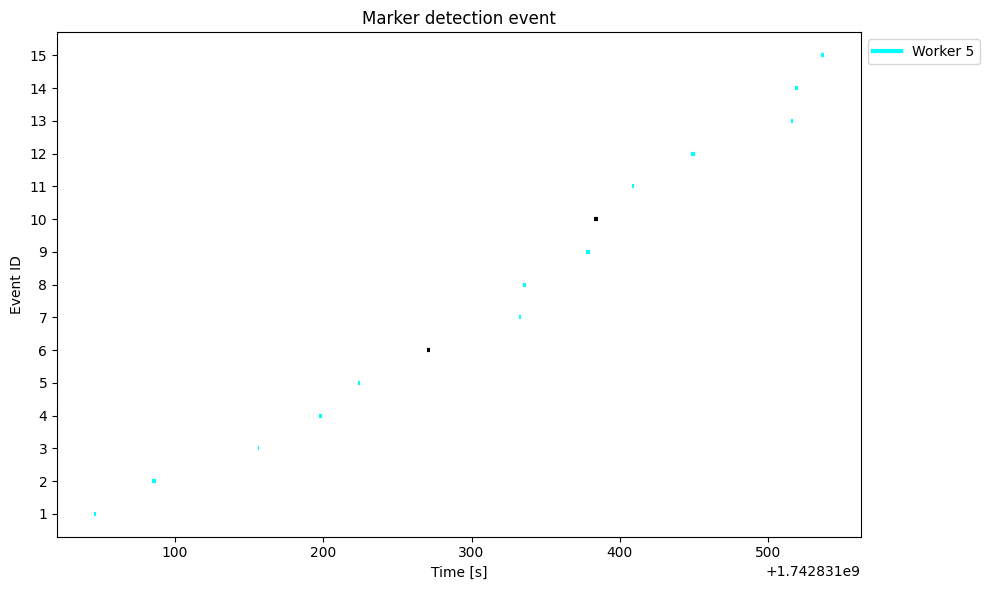

In [4]:
display(hazard_events_plot)

In [5]:
input_folder = "/home/avi/Desktop/robomason/_workingdata/_constructionruns/construction_run_05"
html_file = ui.create_construction_summary_html(input_folder)
ui.open_html_in_browser(html_file)

In [6]:
#go to pickup location
    #pu_pos, ct_pos, st_pos = scan_site(frame_handler, use_stub = True)
    #pickup_loaction = pu_pos
    #moveJ(pcikuplocation)
#Orient
    #
#find object
    #_, ids = MarkerDetector.find_objects(img)
#Align 
    #x_offset = 
    #y_offset = 
    #robot.tranlate((x_offset,y_offset,0),ACC,VEL)
#Go down
    #z_level = 
    #Get own position.
        #Compute new position
    #Go-to new position
#Close_gripper
    #Gripper_width = 
#Move up
    #translate((0,0,-0.06),ACC,VEl)

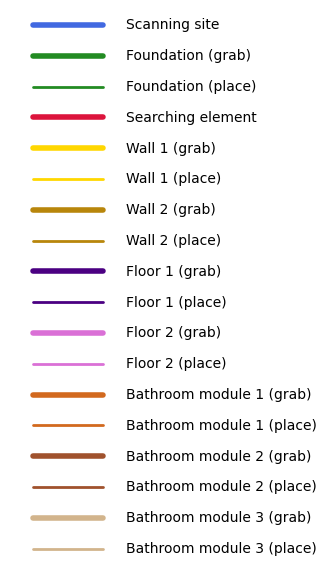

In [10]:
import matplotlib.pyplot as plt

# Your specified colors
ELEMENT_COLORS = {
    "Scanning site":        "royalblue",
    "Foundation":           "forestgreen",
    "Searching element":    "crimson",
    "Wall 1":               "gold",
    "Wall 2":               "darkgoldenrod",
    "Floor 1":              "indigo",
    "Floor 2":              "orchid",
    "Bathroom module 1":    "chocolate",
    "Bathroom module 2":    "sienna",
    "Bathroom module 3":    "tan",
}

# Define the legend entries
# - "Scanning site" & "Searching element": single entry, thicker line
# - Others: grab (thick) + place (thin)
legend_entries = [
    {"label": "Scanning site", "element": "Scanning site", "line_width": 4},
    {"label": "Foundation (grab)", "element": "Foundation", "line_width": 4},
    {"label": "Foundation (place)", "element": "Foundation", "line_width": 2},
    {"label": "Searching element", "element": "Searching element", "line_width": 4},
    {"label": "Wall 1 (grab)", "element": "Wall 1", "line_width": 4},
    {"label": "Wall 1 (place)", "element": "Wall 1", "line_width": 2},
    {"label": "Wall 2 (grab)", "element": "Wall 2", "line_width": 4},
    {"label": "Wall 2 (place)", "element": "Wall 2", "line_width": 2},
    {"label": "Floor 1 (grab)", "element": "Floor 1", "line_width": 4},
    {"label": "Floor 1 (place)", "element": "Floor 1", "line_width": 2},
    {"label": "Floor 2 (grab)", "element": "Floor 2", "line_width": 4},
    {"label": "Floor 2 (place)", "element": "Floor 2", "line_width": 2},
    {"label": "Bathroom module 1 (grab)", "element": "Bathroom module 1", "line_width": 4},
    {"label": "Bathroom module 1 (place)", "element": "Bathroom module 1", "line_width": 2},
    {"label": "Bathroom module 2 (grab)", "element": "Bathroom module 2", "line_width": 4},
    {"label": "Bathroom module 2 (place)", "element": "Bathroom module 2", "line_width": 2},
    {"label": "Bathroom module 3 (grab)", "element": "Bathroom module 3", "line_width": 4},
    {"label": "Bathroom module 3 (place)", "element": "Bathroom module 3", "line_width": 2},
]

n_entries = len(legend_entries)

# Figure size: narrow width, enough height for all entries
fig_width = 3.0              # inches
fig_height_per_item = 0.4    # inches per legend entry
fig_height = n_entries * fig_height_per_item

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')  # hide axes/ticks

# Plot each legend entry: line + label
for i, entry in enumerate(legend_entries):
    # Vertical position from top (i=0) to bottom (i=n_entries-1)
    y = n_entries - i - 0.5  # 0.5 offset to center text
    
    # Draw line
    ax.plot([0.1, 0.4], [y, y],
            color=ELEMENT_COLORS[entry["element"]],
            lw=entry["line_width"],
            solid_capstyle='round')
    
    # Place text
    ax.text(0.5, y, entry["label"],
            va='center',
            fontsize=10,
            fontfamily='sans-serif')

# Set minimal x/y-limits, rely on tight layout to trim whitespace
ax.set_xlim(0, 1.0)
ax.set_ylim(0, n_entries)

# Save as SVG, no extra space
plt.savefig("legend.svg", format="svg", bbox_inches='tight', pad_inches=0)
plt.show()


In [13]:
# Path to the file
file_path = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_Construction_state/_stage.txt'

# Dummy data to write
new_content = str(5)

# Open the file in write mode to overwrite its contents
with open(file_path, 'w') as file:
    file.write(new_content)

print(f"File '{file_path}' successfully overwritten.")


File '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_Construction_state/_stage.txt' successfully overwritten.


In [ ]:
# Path to the file
file_path = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_Construction_state/_stage.txt'


with open(file_path, 'r') as file:
    existing_content = int(file.read())

print("Existing content:")
print(existing_content)

Existing content:
6


In [ ]:
def check_continue():
    file_path = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_Construction_state/_stage.txt'

    with open(file_path, 'r') as file:
        index = int(file.read())
    return index

def update_continue(param):
    # Path to the file
    file_path = '/home/avi/Desktop/robomason/_workingdata/_siteinfo/_Construction_state/_stage.txt'
    index = str(param)
    with open(file_path, 'w') as file:
        file.write(index)